In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath('../src'))

from build_hourly_load import (
    build_city_median_hourly_load
)

In [2]:
# Load NJ metadata
nj = pd.read_parquet("../data/baseline.parquet").reset_index(drop=False)

# Identify New Jersey building IDs

# Example building IDs; replace with actual IDs as needed.
bldg_ids = nj[nj['in.state'] == 'NJ']['bldg_id'].astype(str).unique().tolist()


In [3]:
csv_paths = build_city_median_hourly_load(
    bldg_ids=bldg_ids,
    metadata_df=nj,
    upgrades=("0",),
    state="NJ",
    output_dir="../data/nj_hourly_profiles_by_city",
    metadata_id_col="bldg_id",
)

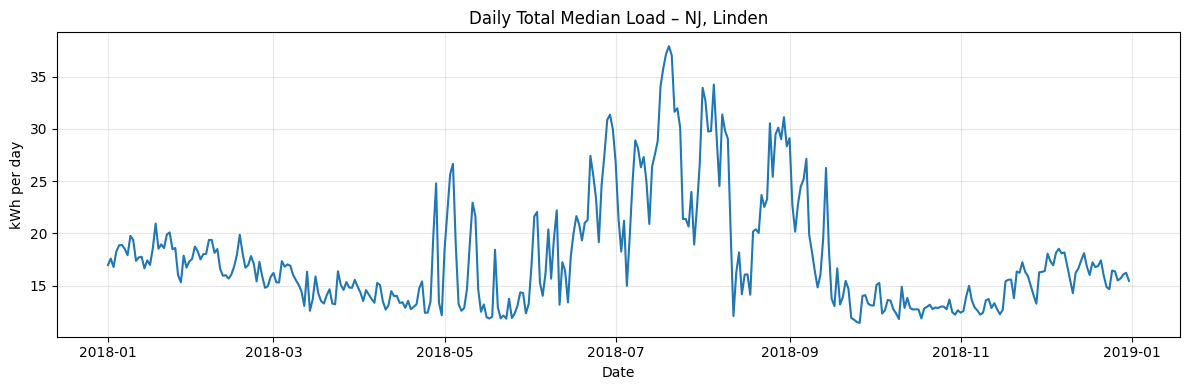

In [5]:
# Plot to check

data_dir = Path("../data/nj_hourly_profiles_by_city")

# Example: pick one file explicitly
city_file = data_dir / "NJ_Linden.csv"

df = pd.read_csv(city_file, parse_dates=["ts_hour"])
df = df.sort_values("ts_hour")

# Daily total energy
daily = (
    df.set_index("ts_hour")["median_kwh"]
    .resample("D")
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(daily.index, daily.values)
ax.set_title(f"Daily Total Median Load – {df['city'].iloc[0]}")
ax.set_xlabel("Date")
ax.set_ylabel("kWh per day")
ax.grid(True, alpha=0.3)

fig.tight_layout()